# Multi-Label Protein Function Prediction with Classifier Chains

## Goal

This notebook predicts multiple biological category labels for each yeast observation.

Unlike ordinary classification, one observation can belong to several categories simultaneously.

For example, a hypothetical observation could have the target:

`Class 2, Class 5, Class 8`

The model must decide independently whether each possible label applies.

## Models

### Frequency baseline

Predicts the same set of common labels for every observation.

### Binary relevance

Trains one independent logistic regression model for each label.

This approach is simple but ignores relationships between labels.

### Classifier chain

Trains the labels in a sequence.

Each classifier receives:

- the original features
- predictions from earlier labels in the chain

This allows later predictions to use label-dependency information.

### Ensemble of classifier chains

Several randomly ordered chains are fitted.

Their probabilities are averaged to reduce dependence on one arbitrary label order.

## Threshold selection

A probability must be converted into a binary decision.

The notebook compares:

- the default threshold of 0.50
- one globally tuned threshold
- separately tuned thresholds for each label

## Evaluation

- Exact-set accuracy
- Sample Jaccard similarity
- Micro F1
- Macro F1
- Sample F1
- Micro Average Precision
- Macro Average Precision
- Hamming loss
- Label-cardinality error
- Empty-prediction rate

## Additional analysis

- Label prevalence
- Label cardinality and density
- Label co-occurrence
- Chain-order variation
- Threshold sensitivity
- Performance by individual label
- Performance by number of true labels
- Label-count calibration
- Random prediction examples
- Worst prediction examples
- Robustness to feature noise

## Main question

Does modelling relationships between labels improve prediction compared with treating every label independently?

In [14]:
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    hamming_loss,
    jaccard_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.multioutput import ClassifierChain
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20

NUMBER_OF_CHAINS = 5

THRESHOLD_VALUES = np.arange(
    0.10,
    0.91,
    0.05
)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)


set_seed(RANDOM_STATE)

print("Random state:", RANDOM_STATE)
print("Number of chains:", NUMBER_OF_CHAINS)

Random state: 42
Number of chains: 5


In [15]:
import pandas as pd

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "shwetajoshi601/yeast-multilabel-classifier/"
    "refs/heads/master/data/yeast.csv"
)

# Load a CSV copy without contacting OpenML
yeast_df = pd.read_csv(DATA_URL)

feature_columns = [f"Att{i}" for i in range(1, 104)]
label_columns = [f"Class{i}" for i in range(1, 15)]

X_raw = yeast_df[feature_columns].copy()
Y_raw = yeast_df[label_columns].copy()

# Match the TRUE/FALSE representation returned by OpenML.
# This keeps the remaining notebook cells compatible.
Y_raw = Y_raw.replace({
    1: "TRUE",
    0: "FALSE"
})

data_source = "Yeast multilabel CSV mirror"

print("Data source:", data_source)
print("Feature shape:", X_raw.shape)
print("Target shape:", Y_raw.shape)
print("\nTarget preview:")
display(Y_raw.head())

Data source: Yeast multilabel CSV mirror
Feature shape: (2417, 103)
Target shape: (2417, 14)

Target preview:


,Class1,Class2,Class3,Class4,Class5,Class6,Class7,Class8,Class9,Class10,Class11,Class12,Class13,Class14
0,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,FALSE,FALSE,FALSE,TRUE,TRUE,FALSE
1,FALSE,FALSE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
2,FALSE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,FALSE
3,FALSE,FALSE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
4,FALSE,FALSE,TRUE,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE


In [16]:
X = X_raw.copy()

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

if X.isna().any().any():
    X = X.fillna(
        X.median()
    )

Y = Y_raw.copy()

Y = Y.apply(
    lambda column:
        column
        .astype(str)
        .str.upper()
        .eq("TRUE")
        .astype(int)
)

feature_names = X.columns.tolist()
label_names = Y.columns.tolist()

print("Clean feature shape:", X.shape)
print("Clean label shape:", Y.shape)
print("Missing feature values:", X.isna().sum().sum())
print("Label names:", label_names)

Clean feature shape: (2417, 103)
Clean label shape: (2417, 14)
Missing feature values: 0
Label names: ['Class1', 'Class2', 'Class3', 'Class4', 'Class5', 'Class6', 'Class7', 'Class8', 'Class9', 'Class10', 'Class11', 'Class12', 'Class13', 'Class14']


## Data loading 

The dataset contained:

- 2,417 observations
- 103 numeric predictors
- 14 possible labels
- 0 missing feature values after cleaning

The notebook loaded the data from a CSV mirror of the Yeast multi-label dataset.

The target was represented as a 2,417 × 14 binary indicator matrix.

For every observation:

- `1` indicated that a label applied
- `0` indicated that the label did not apply
- several target columns could contain `1` simultaneously

The target was therefore multi-label rather than multiclass. The model had to predict an entire set of applicable labels for each observation.

In [17]:
label_counts_per_observation = (
    Y.sum(axis=1)
)

label_cardinality = float(
    label_counts_per_observation.mean()
)

label_density = (
    label_cardinality
    / Y.shape[1]
)

dataset_summary_df = pd.DataFrame({
    "metric": [
        "Observations",
        "Features",
        "Labels",
        "Minimum labels per observation",
        "Maximum labels per observation",
        "Mean labels per observation",
        "Median labels per observation",
        "Label density",
        "Distinct label combinations"
    ],
    "value": [
        len(X),
        X.shape[1],
        Y.shape[1],
        label_counts_per_observation.min(),
        label_counts_per_observation.max(),
        label_cardinality,
        label_counts_per_observation.median(),
        label_density,
        Y.astype(str)
        .agg("".join, axis=1)
        .nunique()
    ]
})

dataset_summary_df

,metric,value
0,Observations,2417.000000
1,Features,103.000000
2,Labels,14.000000
3,Minimum labels per observation,1.000000
4,Maximum labels per observation,11.000000
5,Mean labels per observation,4.237071
6,Median labels per observation,4.000000
7,Label density,0.302648
8,Distinct label combinations,198.000000


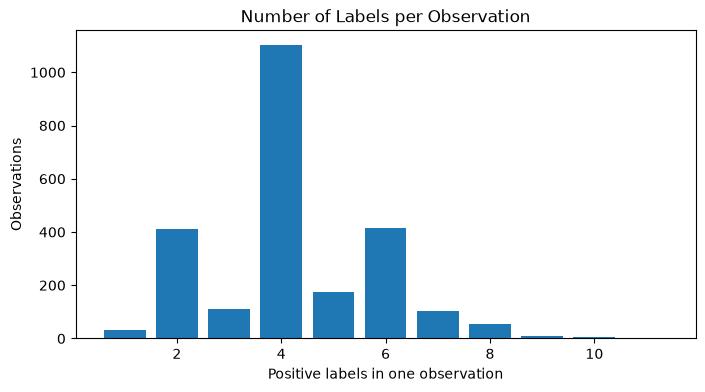

In [18]:
label_count_distribution = (
    label_counts_per_observation
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4))

plt.bar(
    label_count_distribution.index,
    label_count_distribution.values
)

plt.title(
    "Number of Labels per Observation"
)

plt.xlabel(
    "Positive labels in one observation"
)

plt.ylabel("Observations")
plt.show()

## Label cardinality 

The dataset had:

- Minimum labels per observation: 1
- Maximum labels per observation: 11
- Mean labels per observation: 4.2371
- Median labels per observation: 4
- Label density: 0.3026
- Distinct label combinations: 198

Four positive labels was the most common label count by a large margin.

The density of 0.3026 means that approximately 30.3% of the fourteen possible labels were positive for an average observation.

This is not a task where the model normally selects only one category. A useful prediction typically needs to contain several labels.

Exact-set accuracy is especially strict in this setting. All fourteen positive and negative decisions must be correct simultaneously for an observation to count as an exact match.

In [19]:
label_prevalence = (
    Y.mean(axis=0)
)

label_support = (
    Y.sum(axis=0)
)

label_distribution_df = pd.DataFrame({
    "label": label_names,
    "positive_observations":
        label_support.values,
    "prevalence":
        label_prevalence.values
}).sort_values(
    "prevalence",
    ascending=False
).reset_index(drop=True)

label_distribution_df

,label,positive_observations,prevalence
0,Class12,1816,0.751345
1,Class13,1799,0.744311
2,Class2,1038,0.429458
3,Class3,983,0.406703
4,Class4,862,0.356640
5,Class1,762,0.315267
6,Class5,722,0.298717
7,Class6,597,0.247000
8,Class8,480,0.198593
9,Class7,428,0.177079


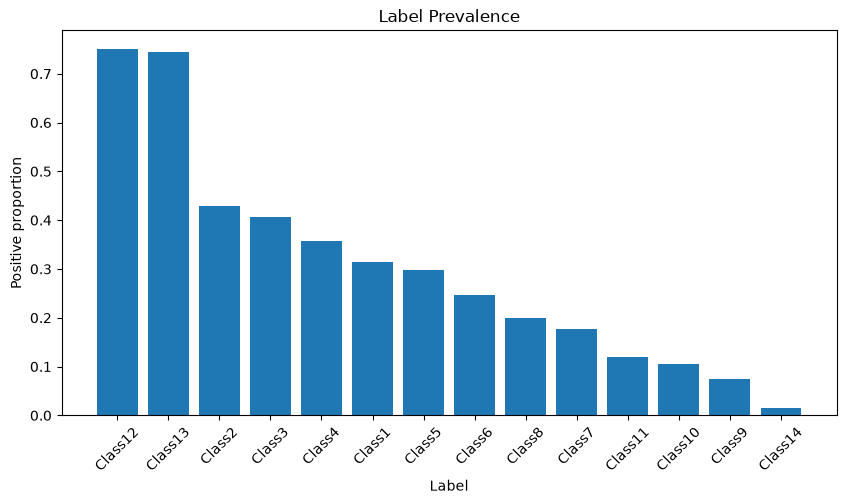

In [20]:
plt.figure(figsize=(10, 5))

plt.bar(
    label_distribution_df["label"],
    label_distribution_df[
        "prevalence"
    ]
)

plt.title("Label Prevalence")
plt.xlabel("Label")
plt.ylabel("Positive proportion")
plt.xticks(rotation=45)
plt.show()

## Label imbalance 

Label prevalence ranged from 1.41% to 75.13%.

The most common labels were:

| Label | Positive observations | Prevalence |
|---|---:|---:|
| Class12 | 1,816 | 0.7513 |
| Class13 | 1,799 | 0.7443 |
| Class2 | 1,038 | 0.4295 |
| Class3 | 983 | 0.4067 |
| Class4 | 862 | 0.3566 |

The rarest labels were:

| Label | Positive observations | Prevalence |
|---|---:|---:|
| Class14 | 34 | 0.0141 |
| Class9 | 178 | 0.0736 |
| Class10 | 253 | 0.1047 |
| Class11 | 289 | 0.1196 |

Class12 and Class13 appeared in approximately three quarters of all observations, while Class14 appeared in only 34 rows.

This imbalance occurred separately for every target label. A model could perform well on common labels while almost completely failing on rare ones.

The very small support of Class14 made its threshold and evaluation metrics particularly unstable.

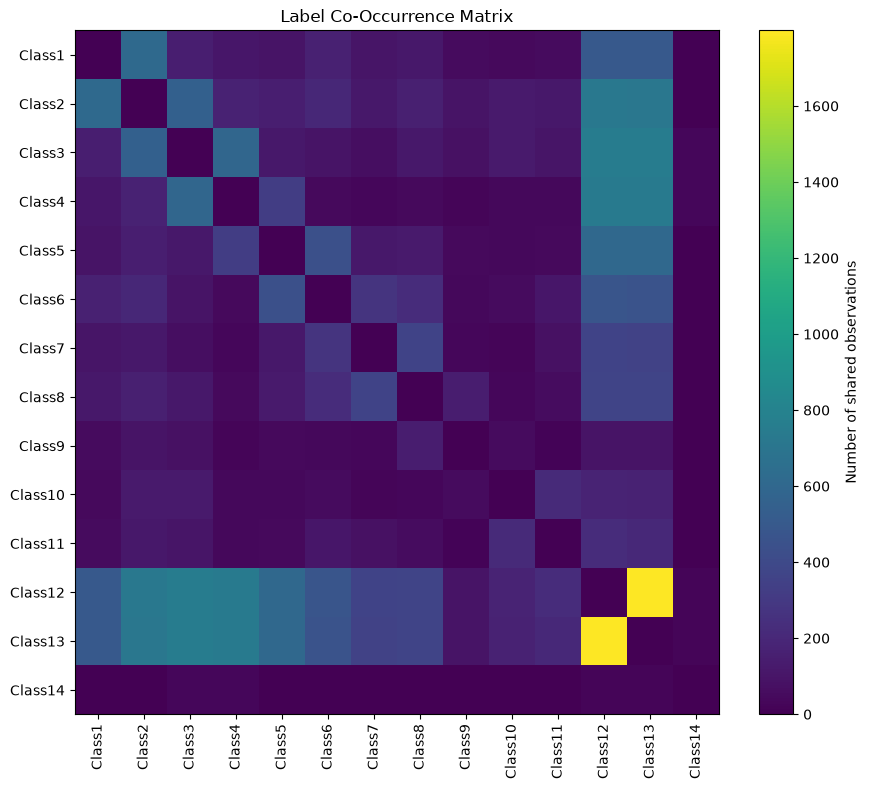

In [21]:
cooccurrence_matrix = (
    Y.T @ Y
)

cooccurrence_matrix = (
    cooccurrence_matrix.astype(float)
)

np.fill_diagonal(
    cooccurrence_matrix.values,
    0
)

plt.figure(figsize=(9, 8))

plt.imshow(
    cooccurrence_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Number of shared observations"
)

plt.xticks(
    range(len(label_names)),
    label_names,
    rotation=90
)

plt.yticks(
    range(len(label_names)),
    label_names
)

plt.title("Label Co-Occurrence Matrix")
plt.tight_layout()
plt.show()

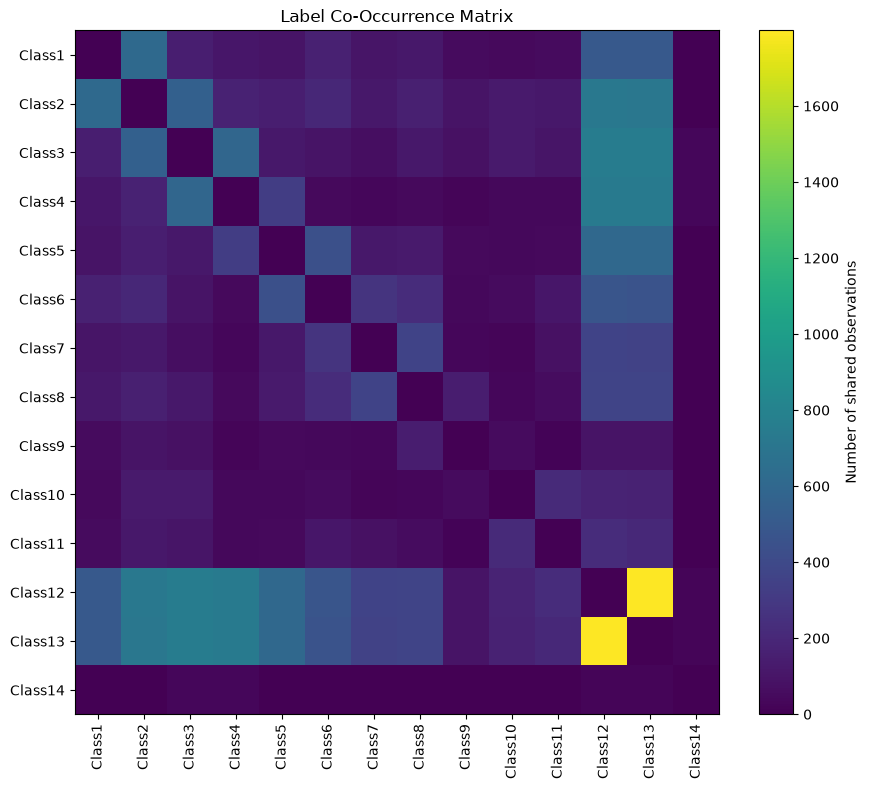

In [22]:
cooccurrence_matrix = (
    Y.T @ Y
)

cooccurrence_matrix = (
    cooccurrence_matrix.astype(float)
)

np.fill_diagonal(
    cooccurrence_matrix.values,
    0
)

plt.figure(figsize=(9, 8))

plt.imshow(
    cooccurrence_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Number of shared observations"
)

plt.xticks(
    range(len(label_names)),
    label_names,
    rotation=90
)

plt.yticks(
    range(len(label_names)),
    label_names
)

plt.title("Label Co-Occurrence Matrix")
plt.tight_layout()
plt.show()

## Label relationship 

The co-occurrence heatmap showed that the strongest relationship was between:

`Class12 and Class13`

These two labels were both highly prevalent and appeared together very frequently.

Other visible co-occurrence patterns included:

- Class2 with Class12 and Class13
- Class3 with Class12 and Class13
- Class4 with Class12 and Class13
- Class1 with Class12 and Class13
- Class5 with Class6
- Class7 with Class8
- Class10 with Class11

These patterns suggested that label predictions could contain useful information about other labels.

However, frequent co-occurrence does not establish causation. It also does not guarantee that classifier chains will improve prediction, because an incorrect early chain prediction can propagate into later classifiers.

In [23]:
(
    X_train_validation,
    X_test,
    Y_train_validation,
    Y_test
) = train_test_split(
    X,
    Y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

validation_fraction_remaining = (
    VALIDATION_SIZE
    / (1 - TEST_SIZE)
)

(
    X_train,
    X_validation,
    Y_train,
    Y_validation
) = train_test_split(
    X_train_validation,
    Y_train_validation,
    test_size=
        validation_fraction_remaining,
    random_state=RANDOM_STATE,
    shuffle=True
)

X_train = X_train.reset_index(drop=True)
X_validation = X_validation.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

Y_train = Y_train.reset_index(drop=True)
Y_validation = Y_validation.reset_index(drop=True)
Y_test = Y_test.reset_index(drop=True)

split_summary_df = pd.DataFrame({
    "split": [
        "Training",
        "Validation",
        "Test"
    ],
    "observations": [
        len(X_train),
        len(X_validation),
        len(X_test)
    ],
    "mean_label_cardinality": [
        Y_train.sum(axis=1).mean(),
        Y_validation.sum(axis=1).mean(),
        Y_test.sum(axis=1).mean()
    ]
})

split_summary_df

,split,observations,mean_label_cardinality
0,Training,1449,4.212560
1,Validation,484,4.291322
2,Test,484,4.256198


In [24]:
split_prevalence_df = pd.DataFrame({
    "label": label_names,
    "training":
        Y_train.mean(axis=0).values,
    "validation":
        Y_validation.mean(axis=0).values,
    "test":
        Y_test.mean(axis=0).values
})

split_prevalence_df

,label,training,validation,test
0,Class1,0.308489,0.305785,0.345041
1,Class2,0.428571,0.425620,0.435950
2,Class3,0.403727,0.417355,0.404959
3,Class4,0.353347,0.369835,0.353306
4,Class5,0.298827,0.299587,0.297521
5,Class6,0.240166,0.252066,0.262397
6,Class7,0.185645,0.171488,0.157025
7,Class8,0.209110,0.194215,0.171488
8,Class9,0.078675,0.070248,0.061983
9,Class10,0.103520,0.099174,0.113636


## Data split 

The random split produced:

| Split | Observations | Mean label cardinality |
|---|---:|---:|
| Training | 1,449 | 4.2126 |
| Validation | 484 | 4.2913 |
| Test | 484 | 4.2562 |

The mean label count remained similar across all three subsets.

Label prevalence was also reasonably preserved, although ordinary random splitting did create some differences.

Examples included:

- Class1: 30.85% in training and 34.50% in testing
- Class8: 20.91% in training and 17.15% in testing
- Class14: 1.24% in training and 1.45% in testing

Every label remained represented in all three sets.

The validation set was used to choose global and label-specific probability thresholds. The test set remained separate until the final model comparison.

The split did not use a specialised iterative multi-label stratification method, so exact preservation of all label combinations was not guaranteed.

In [25]:
def calculate_multilabel_metrics(
    true_labels,
    predicted_labels,
    probabilities=None
):
    true_labels = np.asarray(
        true_labels,
        dtype=int
    )

    predicted_labels = np.asarray(
        predicted_labels,
        dtype=int
    )

    true_cardinality = (
        true_labels.sum(axis=1)
    )

    predicted_cardinality = (
        predicted_labels.sum(axis=1)
    )

    metrics = {
        "subset_accuracy":
            accuracy_score(
                true_labels,
                predicted_labels
            ),

        "sample_jaccard":
            jaccard_score(
                true_labels,
                predicted_labels,
                average="samples",
                zero_division=0
            ),

        "micro_f1":
            f1_score(
                true_labels,
                predicted_labels,
                average="micro",
                zero_division=0
            ),

        "macro_f1":
            f1_score(
                true_labels,
                predicted_labels,
                average="macro",
                zero_division=0
            ),

        "sample_f1":
            f1_score(
                true_labels,
                predicted_labels,
                average="samples",
                zero_division=0
            ),

        "sample_precision":
            precision_score(
                true_labels,
                predicted_labels,
                average="samples",
                zero_division=0
            ),

        "sample_recall":
            recall_score(
                true_labels,
                predicted_labels,
                average="samples",
                zero_division=0
            ),

        "hamming_loss":
            hamming_loss(
                true_labels,
                predicted_labels
            ),

        "label_count_mae":
            np.mean(
                np.abs(
                    true_cardinality
                    - predicted_cardinality
                )
            ),

        "mean_predicted_labels":
            predicted_cardinality.mean(),

        "empty_prediction_rate":
            np.mean(
                predicted_cardinality == 0
            )
    }

    if probabilities is not None:
        probabilities = np.asarray(
            probabilities,
            dtype=float
        )

        metrics[
            "micro_average_precision"
        ] = average_precision_score(
            true_labels,
            probabilities,
            average="micro"
        )

        metrics[
            "macro_average_precision"
        ] = average_precision_score(
            true_labels,
            probabilities,
            average="macro"
        )

    return metrics

In [26]:
baseline_label_count = max(
    1,
    int(
        round(
            Y_train.sum(axis=1).mean()
        )
    )
)

most_common_label_indices = (
    np.argsort(
        -Y_train.mean(axis=0).to_numpy()
    )[:baseline_label_count]
)

baseline_label_names = [
    label_names[index]
    for index in
    most_common_label_indices
]

baseline_predictions = np.zeros(
    Y_test.shape,
    dtype=int
)

baseline_predictions[
    :,
    most_common_label_indices
] = 1

baseline_probabilities = np.tile(
    Y_train.mean(axis=0).to_numpy(),
    (
        len(Y_test),
        1
    )
)

baseline_metrics = (
    calculate_multilabel_metrics(
        Y_test,
        baseline_predictions,
        baseline_probabilities
    )
)

print(
    "Baseline predicted labels:",
    baseline_label_names
)

pd.DataFrame({
    "metric": baseline_metrics.keys(),
    "value": baseline_metrics.values()
})

Baseline predicted labels: ['Class12', 'Class13', 'Class2', 'Class3']


,metric,value
0,subset_accuracy,0.043388
1,sample_jaccard,0.418266
2,micro_f1,0.569570
3,macro_f1,0.207477
4,sample_f1,0.551336
5,sample_precision,0.587810
6,sample_recall,0.549396
7,hamming_loss,0.253837
8,label_count_mae,1.140496
9,mean_predicted_labels,4.000000


## Frequency baseline 

The baseline predicted the same four labels for every observation:

`Class12, Class13, Class2, Class3`

Four labels were predicted because the rounded mean training cardinality was four.

The baseline achieved:

- Exact-set accuracy: 0.0434
- Sample Jaccard: 0.4183
- Micro F1: 0.5696
- Macro F1: 0.2075
- Sample F1: 0.5513
- Sample precision: 0.5878
- Sample recall: 0.5494
- Hamming loss: 0.2538
- Label-count MAE: 1.1405
- Mean predicted labels: 4.0000
- Empty-prediction rate: 0.0000
- Micro Average Precision: 0.5955
- Macro Average Precision: 0.3040

The baseline was surprisingly competitive on sample Jaccard because the same highly prevalent labels appeared in many true label sets.

However, it could not adapt to individual observations and had very poor macro F1. Rare labels were effectively ignored.

Its high micro Average Precision should also be interpreted carefully. Because all observations received the same probability for each label, the baseline could rank common label columns above rare columns but could not rank different observations within one label.

In [27]:
base_binary_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logistic_regression",
        LogisticRegression(
            solver="liblinear",
            C=1.0,
            class_weight="balanced",
            max_iter=2_000,
            random_state=RANDOM_STATE
        )
    )
])

In [28]:
independent_model = (
    OneVsRestClassifier(
        estimator=
            clone(
                base_binary_pipeline
            ),
        n_jobs=-1
    )
)

independent_start_time = (
    time.perf_counter()
)

independent_model.fit(
    X_train,
    Y_train
)

independent_training_time = (
    time.perf_counter()
    - independent_start_time
)

independent_validation_probabilities = (
    independent_model.predict_proba(
        X_validation
    )
)

independent_test_probabilities = (
    independent_model.predict_proba(
        X_test
    )
)

print(
    "Independent training time:",
    round(
        independent_training_time,
        3
    ),
    "seconds"
)

Independent training time: 3.928 seconds


In [29]:
def create_classifier_chain(
    base_estimator,
    random_state
):
    try:
        return ClassifierChain(
            estimator=clone(
                base_estimator
            ),
            order="random",
            random_state=random_state
        )

    except TypeError:
        return ClassifierChain(
            base_estimator=clone(
                base_estimator
            ),
            order="random",
            random_state=random_state
        )

In [30]:
classifier_chains = []

chain_validation_probabilities = []
chain_test_probabilities = []

chain_training_rows = []

for chain_index in range(
    NUMBER_OF_CHAINS
):
    chain = create_classifier_chain(
        base_binary_pipeline,
        random_state=
            RANDOM_STATE + chain_index
    )

    start_time = time.perf_counter()

    chain.fit(
        X_train,
        Y_train
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    validation_probabilities = (
        chain.predict_proba(
            X_validation
        )
    )

    test_probabilities = (
        chain.predict_proba(
            X_test
        )
    )

    classifier_chains.append(
        chain
    )

    chain_validation_probabilities.append(
        validation_probabilities
    )

    chain_test_probabilities.append(
        test_probabilities
    )

    chain_training_rows.append({
        "chain":
            chain_index + 1,
        "runtime_seconds":
            elapsed_time,
        "order":
            list(chain.order_)
    })

chain_training_df = pd.DataFrame(
    chain_training_rows
)

chain_training_df

,chain,runtime_seconds,order
0,1,0.388457,"[9, 11, 0, 12, 5, 8, 2, 1, 13, 4, 7, 10, 3, 6]"
1,2,0.372202,"[9, 7, 10, 13, 2, 6, 8, 11, 3, 12, 5, 1, 0, 4]"
2,3,0.341655,"[5, 8, 6, 7, 11, 9, 2, 10, 13, 0, 12, 1, 3, 4]"
3,4,0.343484,"[9, 8, 6, 2, 10, 7, 13, 1, 4, 12, 5, 0, 3, 11]"
4,5,0.349043,"[1, 6, 11, 0, 7, 10, 12, 9, 2, 3, 4, 8, 5, 13]"


In [31]:
chain_validation_probability_array = (
    np.stack(
        chain_validation_probabilities,
        axis=0
    )
)

chain_test_probability_array = (
    np.stack(
        chain_test_probabilities,
        axis=0
    )
)

ensemble_validation_probabilities = (
    chain_validation_probability_array
    .mean(axis=0)
)

ensemble_test_probabilities = (
    chain_test_probability_array
    .mean(axis=0)
)

print(
    "Ensemble validation shape:",
    ensemble_validation_probabilities.shape
)

print(
    "Ensemble test shape:",
    ensemble_test_probabilities.shape
)

Ensemble validation shape: (484, 14)
Ensemble test shape: (484, 14)


## Classifier chain 

The notebook fitted five classifier chains.

Each chain used a different random order for the fourteen target labels.

The chain runtimes ranged from approximately:

`0.342 to 0.388 seconds`

A classifier chain lets later classifiers use predictions from earlier labels as additional input variables.

This creates two possible effects:

### Potential benefit

Earlier labels may contain useful information about later labels, particularly when labels frequently co-occur.

### Potential weakness

An incorrect early prediction can become a misleading input for several later classifiers.

Averaging five chains reduced dependence on one arbitrary order, although it did not remove error propagation completely.

In [32]:
DEFAULT_THRESHOLD = 0.50

independent_default_predictions = (
    independent_test_probabilities
    >= DEFAULT_THRESHOLD
).astype(int)

chain_default_predictions = (
    ensemble_test_probabilities
    >= DEFAULT_THRESHOLD
).astype(int)

independent_default_metrics = (
    calculate_multilabel_metrics(
        Y_test,
        independent_default_predictions,
        independent_test_probabilities
    )
)

chain_default_metrics = (
    calculate_multilabel_metrics(
        Y_test,
        chain_default_predictions,
        ensemble_test_probabilities
    )
)

default_comparison_df = pd.DataFrame([
    {
        "model":
            "Independent, threshold 0.50",
        **independent_default_metrics
    },
    {
        "model":
            "Chain ensemble, threshold 0.50",
        **chain_default_metrics
    }
])

default_comparison_df

,model,subset_accuracy,sample_jaccard,micro_f1,macro_f1,sample_f1,sample_precision,sample_recall,hamming_loss,label_count_mae,mean_predicted_labels,empty_prediction_rate,micro_average_precision,macro_average_precision
0,"Independent, threshold 0.50",0.049587,0.38313,0.524452,0.429028,0.507749,0.475215,0.619489,0.332940,2.157025,5.545455,0.002066,0.485703,0.438099
1,"Chain ensemble, threshold 0.50",0.074380,0.37952,0.511271,0.415289,0.493755,0.491151,0.556132,0.319953,1.789256,4.909091,0.000000,0.506658,0.428179


## Default threshold 

At the default threshold of 0.50, the results were:

| Metric | Independent | Chain ensemble |
|---|---:|---:|
| Exact-set accuracy | 0.0496 | 0.0744 |
| Sample Jaccard | 0.3831 | 0.3795 |
| Micro F1 | 0.5245 | 0.5113 |
| Macro F1 | 0.4290 | 0.4153 |
| Sample precision | 0.4752 | 0.4912 |
| Sample recall | 0.6195 | 0.5561 |
| Hamming loss | 0.3329 | 0.3200 |
| Label-count MAE | 2.1570 | 1.7893 |
| Mean predicted labels | 5.5455 | 4.9091 |
| Empty-prediction rate | 0.0021 | 0.0000 |

The independent model achieved better:

- sample Jaccard
- micro F1
- macro F1
- recall

The chain ensemble achieved better:

- exact-set accuracy
- sample precision
- Hamming loss
- label-count MAE

The chain ensemble predicted a label count closer to the true test cardinality of 4.2562.

Therefore, neither model was universally stronger at threshold 0.50. The independent model recovered more true labels, while the chain model produced more conservative and more frequently exact label sets.

In [33]:
def evaluate_thresholds(
    true_labels,
    probabilities,
    threshold_values
):
    rows = []

    for threshold in (
        threshold_values
    ):
        predictions = (
            probabilities
            >= threshold
        ).astype(int)

        metrics = (
            calculate_multilabel_metrics(
                true_labels,
                predictions,
                probabilities
            )
        )

        rows.append({
            "threshold":
                float(threshold),
            **metrics
        })

    return pd.DataFrame(rows)

In [34]:
independent_threshold_df = (
    evaluate_thresholds(
        Y_validation,
        independent_validation_probabilities,
        THRESHOLD_VALUES
    )
)

chain_threshold_df = (
    evaluate_thresholds(
        Y_validation,
        ensemble_validation_probabilities,
        THRESHOLD_VALUES
    )
)

In [35]:
def select_best_global_threshold(threshold_df):
    return float(
        threshold_df
        .sort_values(
            [
                "sample_jaccard",
                "micro_f1",
                "hamming_loss"
            ],
            ascending=[
                False,
                False,
                True
            ]
        )
        .iloc[0][
            "threshold"
        ]
    )

In [36]:
best_independent_threshold = (
    select_best_global_threshold(
        independent_threshold_df
    )
)

best_chain_threshold = (
    select_best_global_threshold(
        chain_threshold_df
    )
)

print(
    "Best independent threshold:",
    best_independent_threshold
)

print(
    "Best chain threshold:",
    best_chain_threshold
)

Best independent threshold: 0.3500000000000001
Best chain threshold: 0.3500000000000001


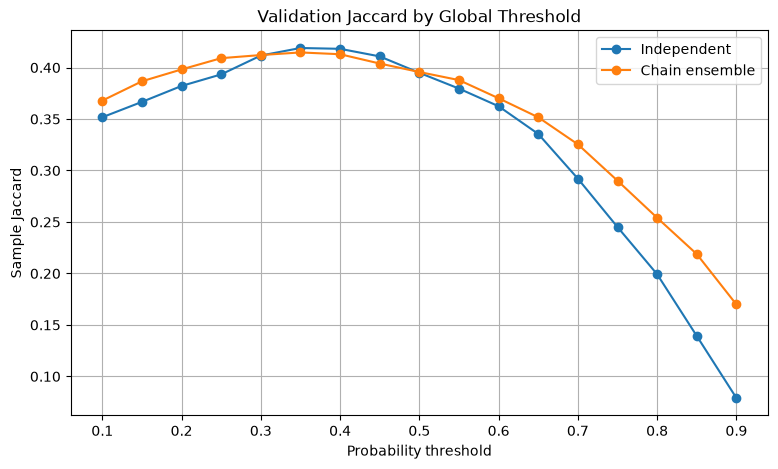

In [37]:
plt.figure(figsize=(9, 5))

plt.plot(
    independent_threshold_df[
        "threshold"
    ],
    independent_threshold_df[
        "sample_jaccard"
    ],
    marker="o",
    label="Independent"
)

plt.plot(
    chain_threshold_df[
        "threshold"
    ],
    chain_threshold_df[
        "sample_jaccard"
    ],
    marker="o",
    label="Chain ensemble"
)

plt.title(
    "Validation Jaccard by Global Threshold"
)

plt.xlabel("Probability threshold")
plt.ylabel("Sample Jaccard")
plt.legend()
plt.grid(True)
plt.show()

## Global threshold 

The best validation threshold was:

- Independent model: 0.35
- Chain ensemble: 0.35

The validation curves peaked around the range:

`0.30 to 0.40`

This indicates that the default threshold of 0.50 was slightly too high for maximising sample Jaccard.

Lowering the threshold increased:

- predicted label count
- sample recall
- the chance of recovering labels with moderate probabilities

However, it also increased:

- false-positive labels
- Hamming loss
- label-count over-prediction

Test results reflected this trade-off.

For the independent model, global tuning changed sample Jaccard from:

`0.3831 to 0.3964`

For the chain ensemble, it changed sample Jaccard from:

`0.3795 to 0.3869`

Thresholds above approximately 0.55 caused a clear decline in Jaccard, particularly for the independent model, because too many true labels were removed.

In [38]:
def tune_label_specific_thresholds(
    true_labels,
    probabilities,
    threshold_values
):
    true_labels = np.asarray(
        true_labels,
        dtype=int
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float
    )

    tuned_thresholds = []

    for label_index in range(
        true_labels.shape[1]
    ):
        best_threshold = 0.50
        best_f1 = -1.0

        for threshold in (
            threshold_values
        ):
            predictions = (
                probabilities[
                    :,
                    label_index
                ]
                >= threshold
            ).astype(int)

            score = f1_score(
                true_labels[
                    :,
                    label_index
                ],
                predictions,
                zero_division=0
            )

            if score > best_f1:
                best_f1 = score
                best_threshold = float(
                    threshold
                )

        tuned_thresholds.append(
            best_threshold
        )

    return np.asarray(
        tuned_thresholds
    )

In [39]:
independent_label_thresholds = (
    tune_label_specific_thresholds(
        Y_validation,
        independent_validation_probabilities,
        THRESHOLD_VALUES
    )
)

chain_label_thresholds = (
    tune_label_specific_thresholds(
        Y_validation,
        ensemble_validation_probabilities,
        THRESHOLD_VALUES
    )
)

label_threshold_df = pd.DataFrame({
    "label": label_names,
    "independent_threshold":
        independent_label_thresholds,
    "chain_threshold":
        chain_label_thresholds,
    "training_prevalence":
        Y_train.mean(axis=0).values
})

label_threshold_df

,label,independent_threshold,chain_threshold,training_prevalence
0,Class1,0.50,0.35,0.308489
1,Class2,0.25,0.10,0.428571
2,Class3,0.30,0.25,0.403727
3,Class4,0.35,0.10,0.353347
4,Class5,0.50,0.25,0.298827
5,Class6,0.65,0.65,0.240166
6,Class7,0.45,0.25,0.185645
7,Class8,0.40,0.25,0.209110
8,Class9,0.65,0.40,0.078675
9,Class10,0.80,0.60,0.103520


## Label specific threshold

Independent-model thresholds ranged from:

`0.10 to 0.90`

Chain thresholds ranged from:

`0.10 to 0.65`

Selected values included:

| Label | Independent | Chain |
|---|---:|---:|
| Class1 | 0.50 | 0.35 |
| Class2 | 0.25 | 0.10 |
| Class3 | 0.30 | 0.25 |
| Class4 | 0.35 | 0.10 |
| Class6 | 0.65 | 0.65 |
| Class9 | 0.65 | 0.40 |
| Class10 | 0.80 | 0.60 |
| Class12 | 0.10 | 0.10 |
| Class13 | 0.10 | 0.10 |
| Class14 | 0.90 | 0.20 |

There was no simple relationship where all rare labels received lower thresholds.

Class12 and Class13 were common labels but received very low thresholds. Class9, Class10, and independent Class14 received high thresholds.

The extreme disagreement for Class14—0.90 for the independent model and 0.20 for the chain model—shows how unstable threshold selection can become when a validation set contains very few positive examples.

Per-label tuning greatly improved the independent model’s sample Jaccard, but it also increased the size of its predicted label sets.

In [40]:
independent_tuned_predictions = (
    independent_test_probabilities
    >= best_independent_threshold
).astype(int)

chain_tuned_predictions = (
    ensemble_test_probabilities
    >= best_chain_threshold
).astype(int)

independent_label_tuned_predictions = (
    independent_test_probabilities
    >= independent_label_thresholds[
        None,
        :
    ]
).astype(int)

chain_label_tuned_predictions = (
    ensemble_test_probabilities
    >= chain_label_thresholds[
        None,
        :
    ]
).astype(int)

In [41]:
model_predictions = {
    "Frequency baseline":
        (
            baseline_predictions,
            baseline_probabilities
        ),

    "Independent, 0.50":
        (
            independent_default_predictions,
            independent_test_probabilities
        ),

    "Independent, global tuned":
        (
            independent_tuned_predictions,
            independent_test_probabilities
        ),

    "Independent, label tuned":
        (
            independent_label_tuned_predictions,
            independent_test_probabilities
        ),

    "Chain ensemble, 0.50":
        (
            chain_default_predictions,
            ensemble_test_probabilities
        ),

    "Chain ensemble, global tuned":
        (
            chain_tuned_predictions,
            ensemble_test_probabilities
        ),

    "Chain ensemble, label tuned":
        (
            chain_label_tuned_predictions,
            ensemble_test_probabilities
        )
}

In [42]:
comparison_rows = []

for model_name, (
    predictions,
    probabilities
) in model_predictions.items():

    metrics = (
        calculate_multilabel_metrics(
            Y_test,
            predictions,
            probabilities
        )
    )

    comparison_rows.append({
        "model": model_name,
        **metrics
    })

model_comparison_df = (
    pd.DataFrame(
        comparison_rows
    )
    .sort_values(
        [
            "sample_jaccard",
            "micro_f1",
            "hamming_loss"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

model_comparison_df

,model,subset_accuracy,sample_jaccard,micro_f1,macro_f1,sample_f1,sample_precision,sample_recall,hamming_loss,label_count_mae,mean_predicted_labels,empty_prediction_rate,micro_average_precision,macro_average_precision
0,"Independent, label tuned",0.037190,0.460498,0.603837,0.448997,0.595447,0.514703,0.785092,0.310803,2.739669,6.727273,0.000000,0.485703,0.438099
1,Frequency baseline,0.043388,0.418266,0.569570,0.207477,0.551336,0.587810,0.549396,0.253837,1.140496,4.000000,0.000000,0.595546,0.304014
2,"Chain ensemble, label tuned",0.033058,0.416366,0.562250,0.437795,0.554713,0.468494,0.761408,0.355962,3.070248,7.128099,0.000000,0.506658,0.428179
3,"Independent, global tuned",0.028926,0.396434,0.544145,0.446410,0.536040,0.439952,0.781781,0.392414,3.721074,7.795455,0.000000,0.485703,0.438099
4,"Chain ensemble, global tuned",0.049587,0.386857,0.528185,0.432732,0.514941,0.455794,0.673583,0.360685,2.648760,6.446281,0.000000,0.506658,0.428179
5,"Independent, 0.50",0.049587,0.383130,0.524452,0.429028,0.507749,0.475215,0.619489,0.332940,2.157025,5.545455,0.002066,0.485703,0.438099
6,"Chain ensemble, 0.50",0.074380,0.379520,0.511271,0.415289,0.493755,0.491151,0.556132,0.319953,1.789256,4.909091,0.000000,0.506658,0.428179


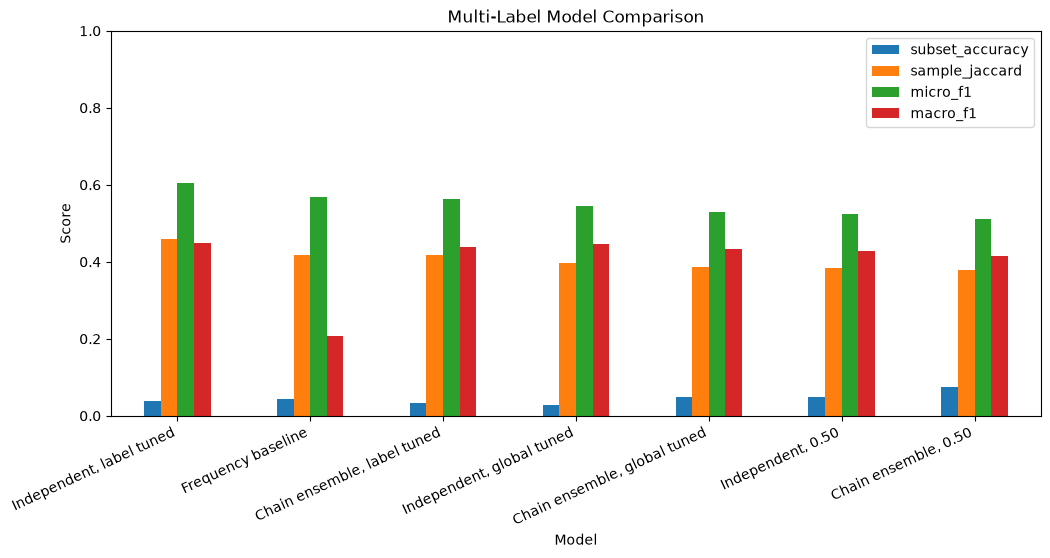

In [43]:
model_comparison_df.set_index(
    "model"
)[
    [
        "subset_accuracy",
        "sample_jaccard",
        "micro_f1",
        "macro_f1"
    ]
].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title(
    "Multi-Label Model Comparison"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.show()

## Final comparison

Final test performance was:

| Model | Exact set | Jaccard | Micro F1 | Macro F1 | Hamming loss | Predicted labels |
|---|---:|---:|---:|---:|---:|---:|
| Frequency baseline | 0.0434 | 0.4183 | 0.5696 | 0.2075 | 0.2538 | 4.0000 |
| Independent, 0.50 | 0.0496 | 0.3831 | 0.5245 | 0.4290 | 0.3329 | 5.5455 |
| Independent, global tuned | 0.0289 | 0.3964 | 0.5441 | 0.4464 | 0.3924 | 7.7955 |
| Independent, label tuned | 0.0372 | 0.4605 | 0.6038 | 0.4490 | 0.3108 | 6.7273 |
| Chain ensemble, 0.50 | 0.0744 | 0.3795 | 0.5113 | 0.4153 | 0.3200 | 4.9091 |
| Chain ensemble, global tuned | 0.0496 | 0.3869 | 0.5282 | 0.4327 | 0.3607 | 6.4463 |
| Chain ensemble, label tuned | 0.0331 | 0.4164 | 0.5623 | 0.4378 | 0.3560 | 7.1281 |

### Strongest overlap-based model

The independent model with label-specific thresholds achieved:

- Highest sample Jaccard: 0.4605
- Highest micro F1: 0.6038
- Highest macro F1: 0.4490
- Highest sample recall: 0.7851
- Lowest learned-model Hamming loss: 0.3108

It was therefore selected as the overall model under the notebook’s Jaccard-first ranking.

### Strongest exact-set model

The chain ensemble at threshold 0.50 achieved the highest exact-set accuracy:

`0.0744`

It exactly matched 36 of the 484 test label sets.

### Label-count trade-off

The selected independent model predicted an average of 6.727 labels, compared with a true average of 4.256.

Its label-count MAE was 2.7397.

The model improved Jaccard mainly by increasing recall, but it often included additional false-positive labels.

### Baseline trade-off

The frequency baseline had:

- lower Jaccard than the selected model
- much lower macro F1
- better Hamming loss
- much better label-count MAE

This demonstrates that the preferred model changes depending on whether the objective is overlap, exact sets, rare-label performance, or label-count calibration.

In [44]:
individual_chain_rows = []

for chain_index in range(
    NUMBER_OF_CHAINS
):
    chain_probabilities = (
        chain_test_probability_array[
            chain_index
        ]
    )

    chain_predictions = (
        chain_probabilities
        >= best_chain_threshold
    ).astype(int)

    chain_metrics = (
        calculate_multilabel_metrics(
            Y_test,
            chain_predictions,
            chain_probabilities
        )
    )

    individual_chain_rows.append({
        "chain":
            chain_index + 1,
        "order":
            list(
                classifier_chains[
                    chain_index
                ].order_
            ),
        **chain_metrics
    })

individual_chain_df = pd.DataFrame(
    individual_chain_rows
)

individual_chain_df[
    [
        "chain",
        "sample_jaccard",
        "micro_f1",
        "macro_f1",
        "hamming_loss"
    ]
]

,chain,sample_jaccard,micro_f1,macro_f1,hamming_loss
0,1,0.376102,0.516449,0.417393,0.360094
1,2,0.391138,0.531144,0.421515,0.345484
2,3,0.363482,0.502980,0.409503,0.369244
3,4,0.351465,0.492617,0.409521,0.380313
4,5,0.381867,0.522818,0.414739,0.351830


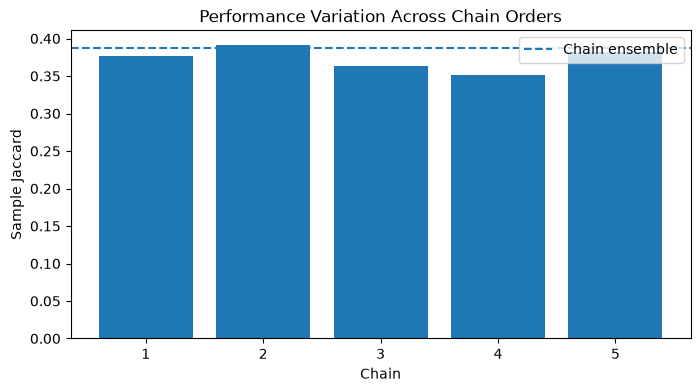

In [45]:
plt.figure(figsize=(8, 4))

plt.bar(
    individual_chain_df[
        "chain"
    ].astype(str),
    individual_chain_df[
        "sample_jaccard"
    ]
)

plt.axhline(
    model_comparison_df.loc[
        model_comparison_df[
            "model"
        ]
        == "Chain ensemble, global tuned",
        "sample_jaccard"
    ].iloc[0],
    linestyle="--",
    label="Chain ensemble"
)

plt.title(
    "Performance Variation Across Chain Orders"
)

plt.xlabel("Chain")
plt.ylabel("Sample Jaccard")
plt.legend()
plt.show()

## Chain-order variation 

Individual chain performance at the tuned global threshold was:

| Chain | Sample Jaccard | Micro F1 | Macro F1 | Hamming loss |
|---:|---:|---:|---:|---:|
| 1 | 0.3761 | 0.5164 | 0.4174 | 0.3601 |
| 2 | 0.3911 | 0.5311 | 0.4215 | 0.3455 |
| 3 | 0.3635 | 0.5030 | 0.4095 | 0.3692 |
| 4 | 0.3515 | 0.4926 | 0.4095 | 0.3803 |
| 5 | 0.3819 | 0.5228 | 0.4147 | 0.3518 |

The strongest individual chain was Chain 2:

`Sample Jaccard = 0.3911`

The weakest was Chain 4:

`Sample Jaccard = 0.3515`

The difference between them was approximately 0.0397.

The ensemble achieved:

`Sample Jaccard = 0.3869`

It outperformed four of the five individual chains, although Chain 2 remained slightly stronger.

This confirms that label order materially affected performance. Ensembling stabilised the result but did not necessarily exceed the single best order.

In [46]:
best_model_name = (
    model_comparison_df
    .iloc[0]["model"]
)

best_predictions, best_probabilities = (
    model_predictions[
        best_model_name
    ]
)

print(
    "Selected best model:",
    best_model_name
)

Selected best model: Independent, label tuned


In [47]:
per_label_rows = []

per_label_average_precision = (
    average_precision_score(
        Y_test,
        best_probabilities,
        average=None
    )
)

for label_index, label_name in enumerate(
    label_names
):
    true_column = (
        Y_test.iloc[
            :,
            label_index
        ].to_numpy()
    )

    predicted_column = (
        best_predictions[
            :,
            label_index
        ]
    )

    per_label_rows.append({
        "label": label_name,
        "test_support":
            int(
                true_column.sum()
            ),
        "prevalence":
            true_column.mean(),
        "precision":
            precision_score(
                true_column,
                predicted_column,
                zero_division=0
            ),
        "recall":
            recall_score(
                true_column,
                predicted_column,
                zero_division=0
            ),
        "f1":
            f1_score(
                true_column,
                predicted_column,
                zero_division=0
            ),
        "average_precision":
            per_label_average_precision[
                label_index
            ]
    })

per_label_performance_df = (
    pd.DataFrame(
        per_label_rows
    )
    .sort_values(
        "f1",
        ascending=False
    )
    .reset_index(drop=True)
)

per_label_performance_df

,label,test_support,prevalence,precision,recall,f1,average_precision
0,Class12,366,0.756198,0.758333,0.994536,0.860520,0.839825
1,Class13,365,0.754132,0.756250,0.994521,0.859172,0.837665
2,Class3,196,0.404959,0.531847,0.852041,0.654902,0.692511
3,Class1,167,0.345041,0.591623,0.676647,0.631285,0.668617
4,Class2,211,0.435950,0.464286,0.924171,0.618067,0.572956
5,Class4,171,0.353306,0.505837,0.760234,0.607477,0.595257
6,Class5,144,0.297521,0.437158,0.555556,0.489297,0.541276
7,Class6,127,0.262397,0.447619,0.370079,0.405172,0.455830
8,Class8,83,0.171488,0.216418,0.698795,0.330484,0.260169
9,Class7,76,0.157025,0.207729,0.565789,0.303887,0.252417


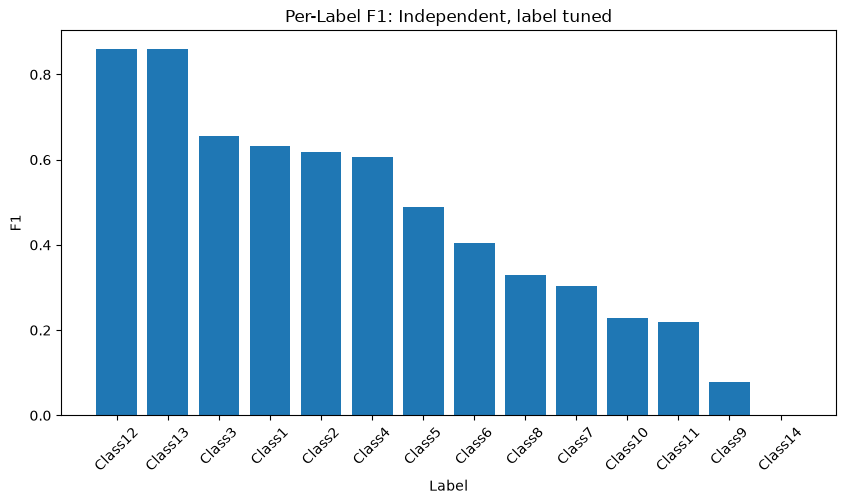

In [48]:
plt.figure(figsize=(10, 5))

plt.bar(
    per_label_performance_df[
        "label"
    ],
    per_label_performance_df[
        "f1"
    ]
)

plt.title(
    f"Per-Label F1: {best_model_name}"
)

plt.xlabel("Label")
plt.ylabel("F1")
plt.xticks(rotation=45)
plt.show()

## Per-label performance 

The selected independent label-tuned model achieved:

| Label | Support | Precision | Recall | F1 | Average Precision |
|---|---:|---:|---:|---:|---:|
| Class12 | 366 | 0.7583 | 0.9945 | 0.8605 | 0.8398 |
| Class13 | 365 | 0.7563 | 0.9945 | 0.8592 | 0.8377 |
| Class3 | 196 | 0.5318 | 0.8520 | 0.6549 | 0.6925 |
| Class1 | 167 | 0.5916 | 0.6766 | 0.6313 | 0.6686 |
| Class2 | 211 | 0.4643 | 0.9242 | 0.6181 | 0.5730 |
| Class4 | 171 | 0.5058 | 0.7602 | 0.6075 | 0.5953 |
| Class5 | 144 | 0.4372 | 0.5556 | 0.4893 | 0.5413 |
| Class6 | 127 | 0.4476 | 0.3701 | 0.4052 | 0.4558 |
| Class8 | 83 | 0.2164 | 0.6988 | 0.3305 | 0.2602 |
| Class7 | 76 | 0.2077 | 0.5658 | 0.3039 | 0.2524 |
| Class10 | 55 | 0.2400 | 0.2182 | 0.2286 | 0.1906 |
| Class11 | 62 | 0.1451 | 0.4516 | 0.2196 | 0.1435 |
| Class9 | 30 | 0.0505 | 0.1667 | 0.0775 | 0.0614 |
| Class14 | 7 | 0.0000 | 0.0000 | 0.0000 | 0.0213 |

Class12 was the strongest label and also had the highest Average Precision.

Class14 was the weakest. None of its seven test positives were correctly predicted.

Class9 was the second-weakest label, with F1 of only 0.0775.

Several labels had high recall but weak precision:

- Class2
- Class7
- Class8
- Class11

The model identified many of their true positives but also produced numerous false positives.

Performance generally declined with support, but prevalence was not the only factor. Feature separability and relationships with other labels also mattered.

In [49]:
independent_best_predictions = (
    independent_tuned_predictions
)

chain_best_predictions = (
    chain_tuned_predictions
)

label_dependency_rows = []

for label_index, label_name in enumerate(
    label_names
):
    true_column = (
        Y_test.iloc[
            :,
            label_index
        ].to_numpy()
    )

    independent_f1 = f1_score(
        true_column,
        independent_best_predictions[
            :,
            label_index
        ],
        zero_division=0
    )

    chain_f1 = f1_score(
        true_column,
        chain_best_predictions[
            :,
            label_index
        ],
        zero_division=0
    )

    total_cooccurrence = (
        cooccurrence_matrix.loc[
            label_name
        ].sum()
    )

    label_dependency_rows.append({
        "label": label_name,
        "independent_f1":
            independent_f1,
        "chain_f1":
            chain_f1,
        "chain_f1_change":
            chain_f1
            - independent_f1,
        "total_training_cooccurrence":
            total_cooccurrence
    })

label_dependency_df = (
    pd.DataFrame(
        label_dependency_rows
    )
    .sort_values(
        "chain_f1_change",
        ascending=False
    )
)

label_dependency_df

,label,independent_f1,chain_f1,chain_f1_change,total_training_cooccurrence
8,Class9,0.114754,0.140969,0.026215,774.0
6,Class7,0.315476,0.338028,0.022552,1916.0
9,Class10,0.228782,0.234818,0.006036,1122.0
0,Class1,0.617925,0.618667,0.000742,2502.0
13,Class14,0.000000,0.000000,0.000000,132.0
7,Class8,0.315789,0.313187,-0.002603,2142.0
1,Class2,0.611307,0.605607,-0.005700,3752.0
10,Class11,0.215190,0.208835,-0.006355,1281.0
2,Class3,0.661191,0.652778,-0.008413,3554.0
5,Class6,0.457547,0.439678,-0.017869,2597.0


## Label dependency benefit 

Using globally tuned predictions, classifier chains produced the largest F1 improvements for:

| Label | Independent F1 | Chain F1 | Change |
|---|---:|---:|---:|
| Class9 | 0.1148 | 0.1410 | +0.0262 |
| Class7 | 0.3155 | 0.3380 | +0.0226 |
| Class10 | 0.2288 | 0.2348 | +0.0060 |
| Class1 | 0.6179 | 0.6187 | +0.0007 |

The largest losses occurred for:

| Label | Independent F1 | Chain F1 | Change |
|---|---:|---:|---:|
| Class4 | 0.6075 | 0.5204 | -0.0871 |
| Class13 | 0.7883 | 0.7273 | -0.0610 |
| Class12 | 0.7957 | 0.7566 | -0.0391 |
| Class5 | 0.5203 | 0.5014 | -0.0189 |
| Class6 | 0.4575 | 0.4397 | -0.0179 |

Classifier chains therefore helped a small number of labels but weakened more labels overall.

Strong co-occurrence did not guarantee an improvement. Class12 and Class13 had the strongest visible relationship but both lost performance under chaining.

This suggests that error propagation and chain order outweighed the available dependency benefit for this dataset and base classifier.

In [50]:
best_analysis_df = pd.DataFrame({
    "true_label_count":
        Y_test.sum(axis=1).to_numpy(),

    "predicted_label_count":
        best_predictions.sum(axis=1)
})

best_analysis_df[
    "exact_set_match"
] = np.all(
    Y_test.to_numpy()
    == best_predictions,
    axis=1
)

sample_jaccard_values = []

for true_row, predicted_row in zip(
    Y_test.to_numpy(),
    best_predictions
):
    intersection = np.logical_and(
        true_row,
        predicted_row
    ).sum()

    union = np.logical_or(
        true_row,
        predicted_row
    ).sum()

    sample_jaccard_values.append(
        intersection / union
        if union > 0
        else 0.0
    )

best_analysis_df[
    "sample_jaccard"
] = sample_jaccard_values

In [52]:
# Create the label-count error for every observation
cardinality_analysis_df = best_analysis_df.copy()

cardinality_analysis_df[
    "label_count_absolute_error"
] = np.abs(
    cardinality_analysis_df[
        "predicted_label_count"
    ].astype(int)
    - cardinality_analysis_df[
        "true_label_count"
    ].astype(int)
)

# Summarise performance by the true number of labels
cardinality_performance_df = (
    cardinality_analysis_df
    .groupby(
        "true_label_count"
    )
    .agg(
        observations=(
            "sample_jaccard",
            "size"
        ),
        exact_set_accuracy=(
            "exact_set_match",
            "mean"
        ),
        mean_sample_jaccard=(
            "sample_jaccard",
            "mean"
        ),
        mean_predicted_labels=(
            "predicted_label_count",
            "mean"
        ),
        label_count_mae=(
            "label_count_absolute_error",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "true_label_count"
    )
)

cardinality_performance_df

,true_label_count,observations,exact_set_accuracy,mean_sample_jaccard,mean_predicted_labels,label_count_mae
0,1,8,0.000000,0.119544,6.250000,5.250000
1,2,83,0.000000,0.205088,7.048193,5.048193
2,3,24,0.000000,0.392493,6.750000,3.750000
3,4,215,0.074419,0.528200,6.506977,2.506977
4,5,33,0.030303,0.487837,6.909091,1.969697
5,6,84,0.011905,0.531033,6.785714,1.500000
6,7,17,0.000000,0.567059,7.058824,1.117647
7,8,16,0.000000,0.566572,6.875000,1.250000
8,9,2,0.000000,0.572727,7.500000,1.500000
9,10,2,0.000000,0.681818,8.500000,1.500000


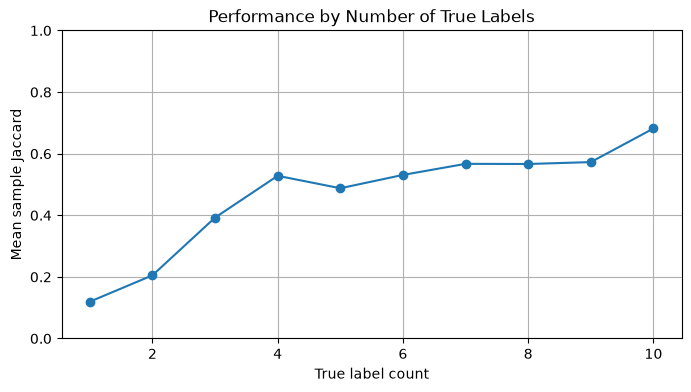

In [53]:
plt.figure(figsize=(8, 4))

plt.plot(
    cardinality_performance_df[
        "true_label_count"
    ],
    cardinality_performance_df[
        "mean_sample_jaccard"
    ],
    marker="o"
)

plt.title(
    "Performance by Number of True Labels"
)

plt.xlabel("True label count")
plt.ylabel("Mean sample Jaccard")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

## Cardinality performance

Performance by true label count was:

| True labels | Observations | Exact-set accuracy | Mean Jaccard | Mean predicted labels | Count MAE |
|---:|---:|---:|---:|---:|---:|
| 1 | 8 | 0.0000 | 0.1195 | 6.2500 | 5.2500 |
| 2 | 83 | 0.0000 | 0.2051 | 7.0482 | 5.0482 |
| 3 | 24 | 0.0000 | 0.3925 | 6.7500 | 3.7500 |
| 4 | 215 | 0.0744 | 0.5282 | 6.5070 | 2.5070 |
| 5 | 33 | 0.0303 | 0.4878 | 6.9091 | 1.9697 |
| 6 | 84 | 0.0119 | 0.5310 | 6.7857 | 1.5000 |
| 7 | 17 | 0.0000 | 0.5671 | 7.0588 | 1.1176 |
| 8 | 16 | 0.0000 | 0.5666 | 6.8750 | 1.2500 |
| 9 | 2 | 0.0000 | 0.5727 | 7.5000 | 1.5000 |
| 10 | 2 | 0.0000 | 0.6818 | 8.5000 | 1.5000 |

The selected model performed very poorly on observations containing only one or two labels.

For true two-label observations, it predicted approximately seven labels on average.

Jaccard increased as the number of true labels increased because the model’s large predicted sets had more opportunities to overlap with large true sets.

The highest Jaccard occurred for ten-label observations, but this group contained only two test cases.

Only eighteen test observations were predicted exactly:

- 16 with four true labels
- 1 with five true labels
- 1 with six true labels

The model systematically over-predicted small label sets and became better calibrated only when the true cardinality was already high.

In [54]:
true_count_distribution = (
    pd.Series(
        Y_test.sum(axis=1).to_numpy()
    )
    .value_counts(
        normalize=True
    )
    .sort_index()
)

predicted_count_distribution = (
    pd.Series(
        best_predictions.sum(axis=1)
    )
    .value_counts(
        normalize=True
    )
    .sort_index()
)

label_count_comparison_df = pd.concat(
    [
        true_count_distribution
        .rename("true_proportion"),

        predicted_count_distribution
        .rename(
            "predicted_proportion"
        )
    ],
    axis=1
).fillna(0)

label_count_comparison_df

,true_proportion,predicted_proportion
1,0.016529,0.000000
2,0.171488,0.000000
3,0.049587,0.002066
4,0.444215,0.078512
5,0.068182,0.150826
6,0.173554,0.219008
7,0.035124,0.216942
8,0.033058,0.208678
9,0.004132,0.090909
10,0.004132,0.030992


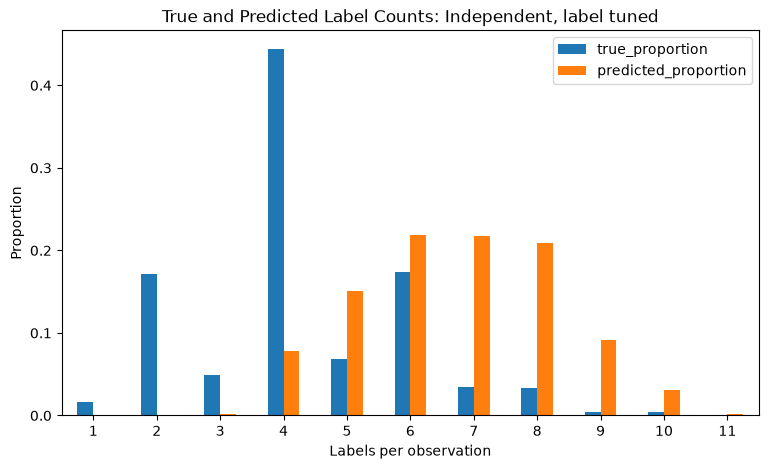

In [55]:
label_count_comparison_df.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    f"True and Predicted Label Counts: "
    f"{best_model_name}"
)

plt.xlabel(
    "Labels per observation"
)

plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

## Label count calibration 

The true test label-count distribution was concentrated around four labels:

- 44.42% of observations had four labels
- 17.36% had six labels
- 17.15% had two labels
- only 7.64% had seven or more labels

The selected model produced a very different distribution:

- It predicted no one-label sets
- It predicted no two-label sets
- Only one observation received three labels
- 21.90% received six labels
- 21.69% received seven labels
- 20.87% received eight labels
- 9.09% received nine labels

The true mean cardinality was:

`4.2562`

The predicted mean cardinality was:

`6.7273`

The model therefore over-predicted by approximately 2.47 labels per observation on average.

Although label-specific threshold tuning maximised sample Jaccard, it did not reproduce the true label-count distribution.

This shows that matching or improving overlap does not necessarily produce well-calibrated set sizes.

In [56]:
def labels_from_binary_row(
    binary_row
):
    return [
        label_names[index]
        for index, value
        in enumerate(binary_row)
        if value == 1
    ]

In [57]:
prediction_rng = np.random.default_rng(
    RANDOM_STATE
)

random_indices = (
    prediction_rng.choice(
        len(Y_test),
        size=12,
        replace=False
    )
)

random_prediction_rows = []

for test_index in random_indices:
    true_labels = labels_from_binary_row(
        Y_test.iloc[
            test_index
        ].to_numpy()
    )

    predicted_labels = labels_from_binary_row(
        best_predictions[
            test_index
        ]
    )

    intersection = len(
        set(true_labels)
        & set(predicted_labels)
    )

    union = len(
        set(true_labels)
        | set(predicted_labels)
    )

    random_prediction_rows.append({
        "test_index":
            int(test_index),
        "true_labels":
            ", ".join(true_labels),
        "predicted_labels":
            ", ".join(
                predicted_labels
            ),
        "sample_jaccard":
            (
                intersection / union
                if union > 0
                else 0.0
            )
    })

random_prediction_df = pd.DataFrame(
    random_prediction_rows
)

random_prediction_df

,test_index,true_labels,predicted_labels,sample_jaccard
0,208,"Class10, Class11","Class2, Class3, Class4, Class9, Class10, Class...",0.250000
1,41,"Class3, Class4, Class12, Class13","Class2, Class3, Class4, Class7, Class8, Class1...",0.571429
2,366,"Class5, Class6, Class8, Class9, Class12, Class13","Class1, Class2, Class3, Class8, Class12, Class13",0.333333
3,254,"Class5, Class6","Class2, Class3, Class7, Class8, Class12, Class13",0.000000
4,310,"Class2, Class3, Class5, Class6, Class10, Class...","Class2, Class3, Class4, Class6, Class12, Class13",0.555556
5,410,"Class3, Class4, Class12, Class13","Class2, Class3, Class4, Class7, Class12, Class13",0.666667
6,42,"Class4, Class5, Class12, Class13","Class1, Class2, Class3, Class4, Class5, Class1...",0.571429
7,206,"Class1, Class2, Class12, Class13","Class1, Class2, Class5, Class6, Class7, Class1...",0.500000
8,45,"Class1, Class2, Class5, Class6, Class8, Class9","Class1, Class2, Class8, Class12, Class13",0.375000
9,334,"Class3, Class4, Class12, Class13","Class1, Class2, Class4, Class5, Class7, Class8...",0.300000


## Random prediction 

None of the twelve randomly displayed observations was an exact label-set match.

Their sample Jaccard scores ranged from:

`0.0000 to 0.6667`

One of the strongest examples had true labels:

`Class3, Class4, Class12, Class13`

and predicted:

`Class2, Class3, Class4, Class7, Class12, Class13`

The model recovered all four true labels but added two spurious labels, producing Jaccard:

`4 / 6 = 0.6667`

Another example with true labels:

`Class5, Class6`

was predicted as:

`Class2, Class3, Class7, Class8, Class12, Class13`

The two sets had no overlap, giving Jaccard zero.

Most predictions recovered at least part of the correct set, but additional common labels were frequently included.

Class12 and Class13 appeared in many predictions, consistent with their high prevalence and low tuned thresholds.

In [58]:
worst_prediction_rows = []

for test_index in range(
    len(Y_test)
):
    true_row = (
        Y_test.iloc[
            test_index
        ].to_numpy()
    )

    predicted_row = (
        best_predictions[
            test_index
        ]
    )

    true_labels = labels_from_binary_row(
        true_row
    )

    predicted_labels = (
        labels_from_binary_row(
            predicted_row
        )
    )

    true_set = set(true_labels)
    predicted_set = set(
        predicted_labels
    )

    intersection = len(
        true_set & predicted_set
    )

    union = len(
        true_set | predicted_set
    )

    jaccard = (
        intersection / union
        if union > 0
        else 0.0
    )

    false_negatives = sorted(
        true_set - predicted_set
    )

    false_positives = sorted(
        predicted_set - true_set
    )

    worst_prediction_rows.append({
        "test_index":
            test_index,
        "true_labels":
            ", ".join(true_labels),
        "predicted_labels":
            ", ".join(
                predicted_labels
            ),
        "sample_jaccard":
            jaccard,
        "missed_labels":
            ", ".join(
                false_negatives
            ),
        "spurious_labels":
            ", ".join(
                false_positives
            ),
        "total_set_errors":
            (
                len(false_negatives)
                + len(false_positives)
            )
    })

worst_prediction_df = (
    pd.DataFrame(
        worst_prediction_rows
    )
    .sort_values(
        [
            "sample_jaccard",
            "total_set_errors"
        ],
        ascending=[
            True,
            False
        ]
    )
)

worst_prediction_df.head(20)

,test_index,true_labels,predicted_labels,sample_jaccard,missed_labels,spurious_labels,total_set_errors
67,67,"Class5, Class6","Class1, Class2, Class3, Class7, Class8, Class9...",0.000000,"Class5, Class6","Class1, Class11, Class12, Class13, Class2, Cla...",11
218,218,"Class5, Class6","Class2, Class3, Class4, Class8, Class9, Class1...",0.000000,"Class5, Class6","Class10, Class11, Class12, Class13, Class2, Cl...",11
188,188,"Class5, Class6","Class1, Class2, Class3, Class4, Class7, Class8...",0.000000,"Class5, Class6","Class1, Class12, Class13, Class2, Class3, Clas...",10
195,195,"Class5, Class6","Class2, Class3, Class4, Class7, Class8, Class1...",0.000000,"Class5, Class6","Class12, Class13, Class14, Class2, Class3, Cla...",10
436,436,"Class5, Class6","Class1, Class2, Class3, Class10, Class11, Clas...",0.000000,"Class5, Class6","Class1, Class10, Class11, Class12, Class13, Cl...",10
161,161,"Class5, Class6, Class7, Class8","Class2, Class3, Class11, Class12, Class13",0.000000,"Class5, Class6, Class7, Class8","Class11, Class12, Class13, Class2, Class3",9
169,169,"Class6, Class7","Class1, Class2, Class3, Class8, Class9, Class1...",0.000000,"Class6, Class7","Class1, Class12, Class13, Class2, Class3, Clas...",9
278,278,"Class1, Class10, Class11","Class3, Class4, Class8, Class9, Class12, Class13",0.000000,"Class1, Class10, Class11","Class12, Class13, Class3, Class4, Class8, Class9",9
323,323,"Class10, Class11","Class2, Class3, Class4, Class7, Class8, Class1...",0.000000,"Class10, Class11","Class12, Class13, Class2, Class3, Class4, Clas...",9
62,62,"Class5, Class6","Class2, Class3, Class4, Class8, Class12, Class13",0.000000,"Class5, Class6","Class12, Class13, Class2, Class3, Class4, Class8",8


## Failure analysis 

The worst predictions had Jaccard equal to zero, meaning the predicted and true sets shared no labels.

Several of the most severe cases had the true set:

`Class5, Class6`

but received large predicted sets containing labels such as:

- Class1
- Class2
- Class3
- Class7
- Class8
- Class9
- Class11
- Class12
- Class13

The two worst observations each had eleven total set errors:

- both true labels were missed
- nine unrelated labels were added

Other repeated zero-overlap failures involved:

- `Class10, Class11`
- `Class6, Class7`
- `Class1`
- `Class1, Class2`

The failures were therefore not limited to the rarest label.

They were dominated by a combination of:

- missing the complete true set
- over-predicting numerous common labels
- assigning Class12 and Class13 even when they were absent
- poor behaviour on observations with only one or two true labels

The selected threshold strategy strongly favoured recall and large predicted sets, which made these zero-overlap failures particularly severe.

In [59]:
training_feature_standard_deviations = (
    X_train.std()
    .replace(0, 1)
    .to_numpy()
)

NOISE_LEVELS = [
    0.00,
    0.05,
    0.10,
    0.20
]

NOISE_REPETITIONS = 10

In [60]:
def get_selected_probabilities(
    feature_frame
):
    if best_model_name.startswith(
        "Chain"
    ):
        probabilities = np.stack([
            chain.predict_proba(
                feature_frame
            )
            for chain
            in classifier_chains
        ]).mean(axis=0)

    elif best_model_name.startswith(
        "Independent"
    ):
        probabilities = (
            independent_model
            .predict_proba(
                feature_frame
            )
        )

    else:
        probabilities = np.tile(
            Y_train.mean(axis=0).to_numpy(),
            (
                len(feature_frame),
                1
            )
        )

    return probabilities

In [61]:
def apply_selected_thresholds(
    probabilities
):
    if best_model_name == (
        "Independent, 0.50"
    ):
        return (
            probabilities >= 0.50
        ).astype(int)

    if best_model_name == (
        "Independent, global tuned"
    ):
        return (
            probabilities
            >= best_independent_threshold
        ).astype(int)

    if best_model_name == (
        "Independent, label tuned"
    ):
        return (
            probabilities
            >= independent_label_thresholds[
                None,
                :
            ]
        ).astype(int)

    if best_model_name == (
        "Chain ensemble, 0.50"
    ):
        return (
            probabilities >= 0.50
        ).astype(int)

    if best_model_name == (
        "Chain ensemble, global tuned"
    ):
        return (
            probabilities
            >= best_chain_threshold
        ).astype(int)

    if best_model_name == (
        "Chain ensemble, label tuned"
    ):
        return (
            probabilities
            >= chain_label_thresholds[
                None,
                :
            ]
        ).astype(int)

    return baseline_predictions.copy()

In [62]:
noise_rows = []

for noise_level in NOISE_LEVELS:
    repetition_metrics = []

    for repetition in range(
        NOISE_REPETITIONS
    ):
        noise_rng = np.random.default_rng(
            RANDOM_STATE
            + repetition
            + int(
                noise_level * 1_000
            )
        )

        noisy_array = (
            X_test.to_numpy()
            + noise_rng.normal(
                loc=0.0,
                scale=(
                    noise_level
                    * training_feature_standard_deviations
                ),
                size=X_test.shape
            )
        )

        noisy_frame = pd.DataFrame(
            noisy_array,
            columns=feature_names
        )

        noisy_probabilities = (
            get_selected_probabilities(
                noisy_frame
            )
        )

        noisy_predictions = (
            apply_selected_thresholds(
                noisy_probabilities
            )
        )

        metrics = (
            calculate_multilabel_metrics(
                Y_test,
                noisy_predictions,
                noisy_probabilities
            )
        )

        repetition_metrics.append(
            metrics
        )

    noise_rows.append({
        "noise_level":
            noise_level,

        "mean_sample_jaccard":
            np.mean([
                row[
                    "sample_jaccard"
                ]
                for row
                in repetition_metrics
            ]),

        "mean_micro_f1":
            np.mean([
                row["micro_f1"]
                for row
                in repetition_metrics
            ]),

        "mean_macro_f1":
            np.mean([
                row["macro_f1"]
                for row
                in repetition_metrics
            ]),

        "mean_hamming_loss":
            np.mean([
                row["hamming_loss"]
                for row
                in repetition_metrics
            ]),

        "mean_label_count_mae":
            np.mean([
                row["label_count_mae"]
                for row
                in repetition_metrics
            ])
    })

noise_robustness_df = pd.DataFrame(
    noise_rows
)

noise_robustness_df

,noise_level,mean_sample_jaccard,mean_micro_f1,mean_macro_f1,mean_hamming_loss,mean_label_count_mae
0,0.00,0.460498,0.603837,0.448997,0.310803,2.739669
1,0.05,0.460741,0.603930,0.448690,0.310818,2.755992
2,0.10,0.460622,0.603817,0.448707,0.311142,2.746901
3,0.20,0.459449,0.603649,0.449615,0.311615,2.745661


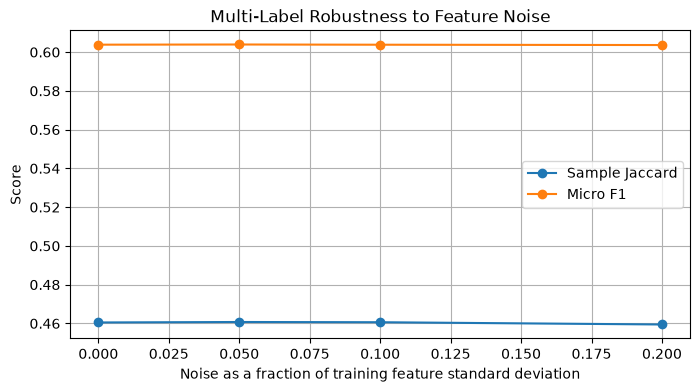

In [63]:
plt.figure(figsize=(8, 4))

plt.plot(
    noise_robustness_df[
        "noise_level"
    ],
    noise_robustness_df[
        "mean_sample_jaccard"
    ],
    marker="o",
    label="Sample Jaccard"
)

plt.plot(
    noise_robustness_df[
        "noise_level"
    ],
    noise_robustness_df[
        "mean_micro_f1"
    ],
    marker="o",
    label="Micro F1"
)

plt.title(
    "Multi-Label Robustness to Feature Noise"
)

plt.xlabel(
    "Noise as a fraction of "
    "training feature standard deviation"
)

plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

## Noise robustness 

Results under Gaussian feature noise were:

| Noise level | Sample Jaccard | Micro F1 | Macro F1 | Hamming loss | Label-count MAE |
|---:|---:|---:|---:|---:|---:|
| 0.00 | 0.4605 | 0.6038 | 0.4490 | 0.3108 | 2.7397 |
| 0.05 | 0.4607 | 0.6039 | 0.4487 | 0.3108 | 2.7560 |
| 0.10 | 0.4606 | 0.6038 | 0.4487 | 0.3111 | 2.7469 |
| 0.20 | 0.4594 | 0.6036 | 0.4496 | 0.3116 | 2.7457 |

Performance remained almost unchanged across all tested noise levels.

At the highest noise level:

- Sample Jaccard declined by only approximately 0.0010
- Micro F1 declined by less than 0.0002
- Macro F1 did not decline
- Hamming loss increased only slightly

There was no substantial degradation within the tested range.

Macro F1 did not fall faster than micro F1, so rare labels were not noticeably more sensitive to this level of Gaussian corruption.

The result suggests that the linear models were highly stable to modest feature perturbations, possibly because the predictors contained redundant information or because the noise was small relative to the class boundaries.